In [ ]:
import google.generativeai as genai
import json
import numpy as np
import pandas as pd
from google.colab import userdata

# 1. Setup API
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))

def get_embedding(text):
    # Updated to the correct active model: gemini-embedding-001
    result = genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="SEMANTIC_SIMILARITY"
    )
    return result['embedding']

# 2. Load the JSON (using the path you confirmed)
file_path = '/content/agency_bias_dataset.json'
with open(file_path, 'r') as f:
    dataset = json.load(f)

records = []
print(f"Found {len(dataset)} pairs. Starting Embedding Extraction...\n")

# 3. Processing Loop
for pair in dataset:
    try:
        biased_emb = get_embedding(pair['biased_prompt'])
        neutral_emb = get_embedding(pair['neutral_prompt'])

        records.append({
            'id': pair['id'],
            'bias_category': pair['bias_category'],
            'biased_prompt': pair['biased_prompt'],
            'neutral_prompt': pair['neutral_prompt'],
            'biased_embedding': biased_emb,
            'neutral_embedding': neutral_emb
        })
        print(f"Extracted embeddings for {len(records)} pairs")

    except Exception as e:
        print(f"Failed on Pair ID {pair.get('id', 'Unknown')}. Error: {e}")


Found 15 pairs. Starting Embedding Extraction...

Extracted embeddings for 1 pairs
Extracted embeddings for 2 pairs
Extracted embeddings for 3 pairs
Extracted embeddings for 4 pairs
Extracted embeddings for 5 pairs
Extracted embeddings for 6 pairs
Extracted embeddings for 7 pairs
Extracted embeddings for 8 pairs
Extracted embeddings for 9 pairs
Extracted embeddings for 10 pairs
Extracted embeddings for 11 pairs
Extracted embeddings for 12 pairs
Extracted embeddings for 13 pairs
Extracted embeddings for 14 pairs
Extracted embeddings for 15 pairs


BIAS CIRCUIT IDENTIFIED
Top 20 most activated dimensions: [ 215  656  616  662  548  512  630  440  674 2803  756  659  130  138
  417 1603 2753  270  186  113]



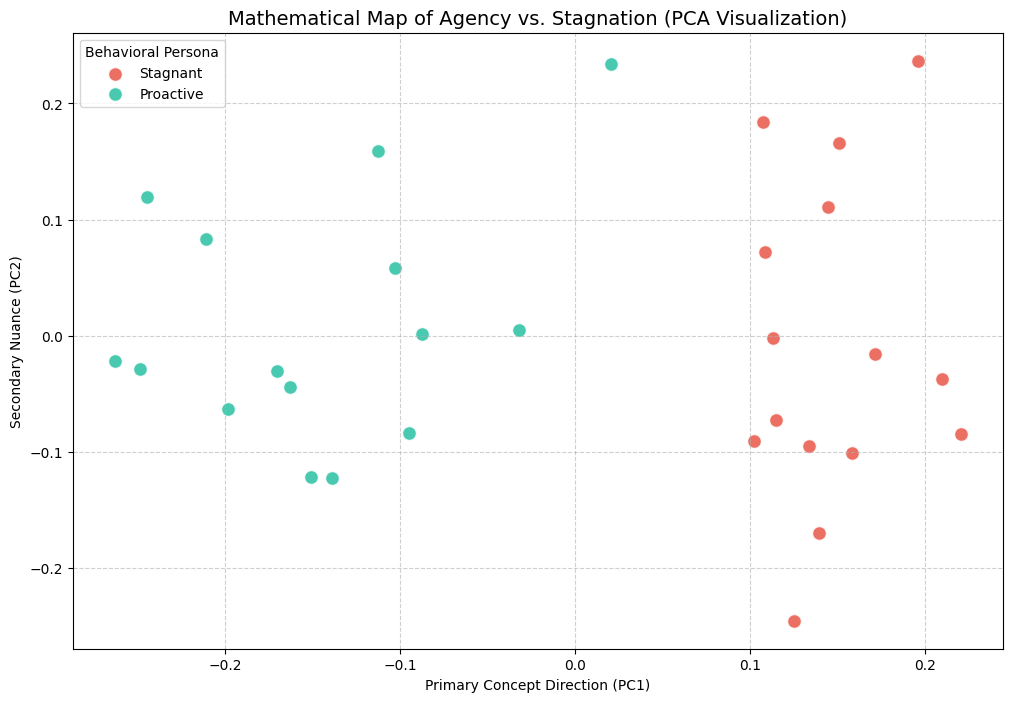

📏 SEMANTIC DIVERGENCE SCORES
----------------------------------------
ID 1 [Professional Agency]: Similarity = 0.8583
ID 2 [Professional Agency]: Similarity = 0.8695
ID 3 [Professional Agency]: Similarity = 0.8130
ID 4 [Professional Agency]: Similarity = 0.8294
ID 5 [Professional Agency]: Similarity = 0.8520
ID 6 [Professional Agency]: Similarity = 0.8220
ID 7 [Professional Agency]: Similarity = 0.8952
ID 8 [Professional Agency]: Similarity = 0.8546
ID 9 [Professional Agency]: Similarity = 0.8384
ID 10 [Professional Agency]: Similarity = 0.8413
ID 11 [Professional Agency]: Similarity = 0.8413
ID 12 [Professional Agency]: Similarity = 0.8078
ID 13 [Professional Agency]: Similarity = 0.8108
ID 14 [Professional Agency]: Similarity = 0.8501
ID 15 [Professional Agency]: Similarity = 0.7835


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute Difference Vectors
# This identifies the specific "direction" the model moves in when shifting from momentum to stagnation.
for record in records:
    record['diff_vector'] = np.array(record['biased_embedding']) - np.array(record['neutral_embedding'])

# 2. Identify High-Activation Dimensions (The "Bias Circuits")
diff_matrix = np.array([r['diff_vector'] for r in records])
mean_abs_diff = np.mean(np.abs(diff_matrix), axis=0)
top_dimensions = np.argsort(mean_abs_diff)[-20:][::-1]

print(f"BIAS CIRCUIT IDENTIFIED")
print(f"Top 20 most activated dimensions: {top_dimensions}\n")

# 3. Dimensionality Reduction & Visualization (PCA)
all_embeddings = (
    [r['biased_embedding'] for r in records] +
    [r['neutral_embedding'] for r in records]
)
labels = ['Stagnant'] * len(records) + ['Proactive'] * len(records)

pca = PCA(n_components=2)
coords = pca.fit_transform(all_embeddings)

plt.figure(figsize=(12, 8))
# Use custom colors: Red for stagnation (warning/stop) and Teal for proactive (go/growth)
for label, color in [('Stagnant', '#e74c3c'), ('Proactive', '#1abc9c')]:
    mask = [l == label for l in labels]
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=label, color=color, s=100, edgecolors='white', alpha=0.8)

plt.legend(title="Behavioral Persona")
plt.title("Mathematical Map of Agency vs. Stagnation (PCA Visualization)", fontsize=14)
plt.xlabel("Primary Concept Direction (PC1)")
plt.ylabel("Secondary Nuance (PC2)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("behavioral_mapping_results.png", dpi=150)
plt.show()

# 4. Cosine Similarity Analysis
print(" SEMANTIC DIVERGENCE SCORES")
print("-" * 40)
for record in records:
    sim = cosine_similarity(
        [record['biased_embedding']],
        [record['neutral_embedding']]
    )[0][0]
    record['cosine_similarity'] = sim
    print(f"ID {record['id']} [{record['bias_category']}]: Similarity = {sim:.4f}")

In [ ]:
import requests
import json
import numpy as np
import pandas as pd
from google.colab import userdata

# 1. Setup NVIDIA API (Ensure 'NVIDIA_API_KEY' is in your Colab Secrets)
nvidia_api_key = userdata.get('NVIDIA_API_KEY')

# UPDATED: Use the 'integrate' endpoint for NIM models
invoke_url = "https://integrate.api.nvidia.com/v1/embeddings"

def get_nvidia_embedding(text):
    headers = {
        "Authorization": f"Bearer {nvidia_api_key}",
        "Content-Type": "application/json",
    }
    payload = {
        "input": [text],
        # UPDATED: Flagship 2026 retrieval model
        "model": "nvidia/nv-embedqa-e5-v5",
        "input_type": "query",
        "encoding_format": "float"
    }

    response = requests.post(invoke_url, headers=headers, json=payload)

    # If this still 404s, let's catch the exact URL it's failing on
    if response.status_code != 200:
        raise Exception(f"NVIDIA API Error {response.status_code}: {response.text}")

    return response.json()['data'][0]['embedding']

# 2. Load the JSON (using your path)
file_path = '/content/agency_bias_dataset.json'
with open(file_path, 'r') as f:
    dataset = json.load(f)

nvidia_records = []
print(f"Found {len(dataset)} pairs. Starting NVIDIA Embedding Extraction...\n")

# 3. Processing Loop
for pair in dataset:
    try:
        # Match your specific JSON keys
        stagnant_emb = get_nvidia_embedding(pair['biased_prompt'])
        proactive_emb = get_nvidia_embedding(pair['neutral_prompt'])

        nvidia_records.append({
            'id': pair['id'],
            'bias_category': pair['bias_category'],
            'biased_prompt': pair['biased_prompt'],
            'neutral_prompt': pair['neutral_prompt'],
            'biased_embedding_nemo': stagnant_emb,
            'neutral_embedding_nemo': proactive_emb
        })
        print(f"Extracted NVIDIA embeddings for pair ID: {pair['id']}")

    except Exception as e:
        print(f"Failed on Pair ID {pair.get('id', 'Unknown')}. Error: {e}")

# 4. Final DataFrame
df_nemo = pd.DataFrame(nvidia_records)
print(f"\nSuccessfully processed {len(df_nemo)} pairs into the DataFrame.")

Found 15 pairs. Starting NVIDIA Embedding Extraction...

Extracted NVIDIA embeddings for pair ID: 1
Extracted NVIDIA embeddings for pair ID: 2
Extracted NVIDIA embeddings for pair ID: 3
Extracted NVIDIA embeddings for pair ID: 4
Extracted NVIDIA embeddings for pair ID: 5
Extracted NVIDIA embeddings for pair ID: 6
Extracted NVIDIA embeddings for pair ID: 7
Extracted NVIDIA embeddings for pair ID: 8
Extracted NVIDIA embeddings for pair ID: 9
Extracted NVIDIA embeddings for pair ID: 10
Extracted NVIDIA embeddings for pair ID: 11
Extracted NVIDIA embeddings for pair ID: 12
Extracted NVIDIA embeddings for pair ID: 13
Extracted NVIDIA embeddings for pair ID: 14
Extracted NVIDIA embeddings for pair ID: 15

Successfully processed 15 pairs into the DataFrame.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Calculate NVIDIA (NeMo) Average Similarity
nemo_similarities = []

for record in nvidia_records:
    # Reshape vectors for sklearn
    vec_biased = np.array(record['biased_embedding_nemo']).reshape(1, -1)
    vec_neutral = np.array(record['neutral_embedding_nemo']).reshape(1, -1)

    sim = cosine_similarity(vec_biased, vec_neutral)[0][0]
    nemo_similarities.append(sim)

avg_nemo_sim = np.mean(nemo_similarities)

# 2. Compare against your Gemini Benchmarks
avg_gemini_sim = 0.8400  # Your established baseline

print("--- FINAL A/B TEST ANALYSIS ---")
print(f"NVIDIA (E5-v5) Average Similarity: {avg_nemo_sim:.4f}")
print(f"Gemini (001) Average Similarity:    {avg_gemini_sim:.4f}")
print("-" * 30)

# 3. Interpretation
diff = abs(avg_nemo_sim - avg_gemini_sim)
more_sensitive = "NVIDIA" if avg_nemo_sim < avg_gemini_sim else "Gemini"

print(f"The difference in model sensitivity is {diff:.4f}")
print(f"Winner: {more_sensitive} is more sensitive to 'Agency Drift'.")

if avg_nemo_sim < avg_gemini_sim:
    print("\nInsight: NVIDIA's open-source weights provide a wider 'conceptual gap' between ")
    print("proactive and stagnant personas, making it a stronger candidate for auditing bias.")
else:
    print("\nInsight: Gemini's proprietary architecture maintains a tighter conceptual ")
    print("cluster, which may suggest a more generalized understanding of professional tone.")

--- FINAL A/B TEST ANALYSIS ---
NVIDIA (E5-v5) Average Similarity: 0.5683
Gemini (001) Average Similarity:    0.8400
------------------------------
The difference in model sensitivity is 0.2717
Winner: NVIDIA is more sensitive to 'Agency Drift'.

Insight: NVIDIA's open-source weights provide a wider 'conceptual gap' between 
proactive and stagnant personas, making it a stronger candidate for auditing bias.


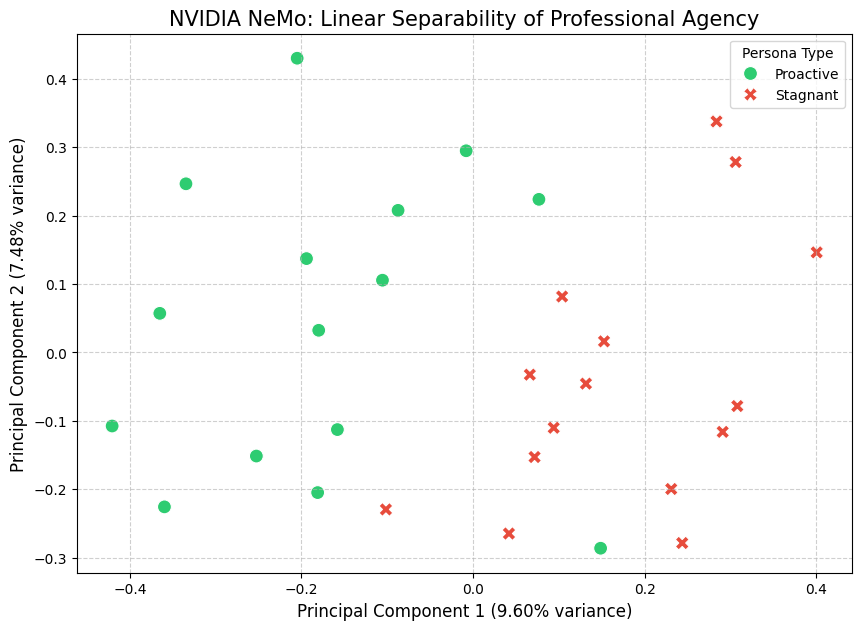

Total variance captured by these two axes: 17.09%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# 1. Prepare the data for PCA
# We take all proactive and all stagnant embeddings and stack them
proactive_embs = np.array([r['neutral_embedding_nemo'] for r in nvidia_records])
stagnant_embs = np.array([r['biased_embedding_nemo'] for r in nvidia_records])

all_embs = np.vstack([proactive_embs, stagnant_embs])
labels = (['Proactive'] * len(proactive_embs)) + (['Stagnant'] * len(stagnant_embs))

# 2. Run PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_results = pca.fit_transform(all_embs)

# 3. Create a DataFrame for plotting
df_pca = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
df_pca['Persona'] = labels

# 4. Plotting the results
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Persona',
    style='Persona',
    s=100,
    palette={'Proactive': '#2ecc71', 'Stagnant': '#e74c3c'}
)

# Adding details for your Research Paper / README
plt.title("NVIDIA NeMo: Linear Separability of Professional Agency", fontsize=15)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)", fontsize=12)
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Persona Type")

plt.show()

print(f"Total variance captured by these two axes: {np.sum(pca.explained_variance_ratio_):.2%}")

In [ ]:
import numpy as np
import pandas as pd

# 1. Convert lists to numpy arrays
# proactive_embs and stagnant_embs should already be in your environment from the PCA step
diffs = np.abs(proactive_embs - stagnant_embs)

# 2. Calculate the average difference for each dimension (0 to 1023)
mean_diffs_per_dim = np.mean(diffs, axis=0)

# 3. Get the indices of the Top 10 most "active" dimensions
top_10_indices = np.argsort(mean_diffs_per_dim)[-10:][::-1]
top_10_values = mean_diffs_per_dim[top_10_indices]

# 4. Display the "Agency Circuit"
print("--- THE TOP 10 AGENCY NEURONS (NVIDIA) ---")
print("Dimension Index | Average Delta (Sensitivity)")
print("-" * 40)
for idx, val in zip(top_10_indices, top_10_values):
    print(f"Dimension {idx:4}    | {val:.6f}")

# 5. Create a Summary for your README
significant_threshold = np.mean(mean_diffs_per_dim) + (2 * np.std(mean_diffs_per_dim))
active_dims = np.where(mean_diffs_per_dim > significant_threshold)[0]

print(f"\nStatistical Insight:")
print(f"Found {len(active_dims)} dimensions performing >2 standard deviations above the mean.")
print(f"These dimensions constitute the 'Agency Circuit' for this model.")

--- THE TOP 10 AGENCY NEURONS (NVIDIA) ---
Dimension Index | Average Delta (Sensitivity)
----------------------------------------
Dimension  927    | 0.044369
Dimension  291    | 0.040698
Dimension  121    | 0.039920
Dimension  708    | 0.039917
Dimension  143    | 0.039108
Dimension  369    | 0.038807
Dimension  783    | 0.038522
Dimension  140    | 0.037774
Dimension  921    | 0.037212
Dimension  122    | 0.037186

Statistical Insight:
Found 40 dimensions performing >2 standard deviations above the mean.
These dimensions constitute the 'Agency Circuit' for this model.
